# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?  

Linear models just output a raw number and that number can go anywhere from negative infinity to positive infinity. If your outcome is a probability or a count or a category, the output should be bounded. GLMs/latent variable models pass the linear predictor through an activation function that maps it to the right space. The output is bounded to make sense for whatever you're trying to model.


2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.  

Cross entropy is the log probability of the observed labels under the predicted distribution. When the model is confident and right, the loss is small. When the model is confident and wrong, the loss is huge. This is different from MSE which treats a wrong confident prediction and a wrong uncertain prediction the same. Cross entropy also comes from maximum likelihood for categorical distributions so it fits well for categorical.


3. True or false, and explain: Logistic regression is a linear model.  

Depends. The latent variable $b \cdot x$ is linear in the features and the coefficients. But the predicted probability is a nonlinear transformation of that. So the model is linear in the log-odds space, but the output is nonlinear in x.


4. True or false, and explain: Logistic regression cannot be used for classification.  

False. It's one of the most common classification methods. You pick a threshold on the predicted probability and assign a class label. That's classification.


5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?  

No. The coefficient is the change in the log-odds for a 1 unit increase in the feature. The effect on the actual predicted probability depends on where you are on the sigmoid curve, so the same coefficient has a different effect at different values of x.


6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False. Logistic regression is linear in the coefficient space, which means it can only produce a linear decision boundary in the feature space. If the actual boundary of what you are modeling is curved, you still need polynomial terms to capture it, just like linear regression.


7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.  

False. Logistic regression is better when your outcome is binary because the predictions are valid probabilities and the loss function makes more sense. But for a continuous outcome, OLS is still the right call. They're different tools for their own cases.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

In [24]:
cols = ['Debtor', 'Tuition fees up to date', 'Scholarship holder',
        'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']

students = pd.read_csv('../data/data.csv', sep=';', usecols=cols)
print(students.shape)
print(students.isna().sum())
students.head()

(4424, 6)
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


No missing values. I used `usecols` to only pull the variables I need.

In [25]:
students['dropout'] = (students['Target'] == 'Dropout').astype(int)
students['dropout'].value_counts()

dropout
0    3003
1    1421
Name: count, dtype: int64

In [26]:
feat_cols = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
X2 = students[feat_cols]
y2 = students['dropout']

lr2 = LogisticRegression(max_iter=1000).fit(X2, y2)
coef_df2 = pd.DataFrame({'feature': feat_cols, 'coef': lr2.coef_[0]})
print(coef_df2)

                   feature      coef
0                   Debtor  0.530625
1  Tuition fees up to date -2.556542
2       Scholarship holder -1.227442
3        Age at enrollment  0.049925


Being a debtor has a positive coefficient, so it predicts higher dropout probability. Being up to date on tuition and being a scholarship holder both have negative coefficients, so they predict lower dropout. Age at enrollment is also positive, older students are slightly more likely to drop out. So being current on tuition has a strong negative effect on dropout risk, which is probably the biggest predictor here.

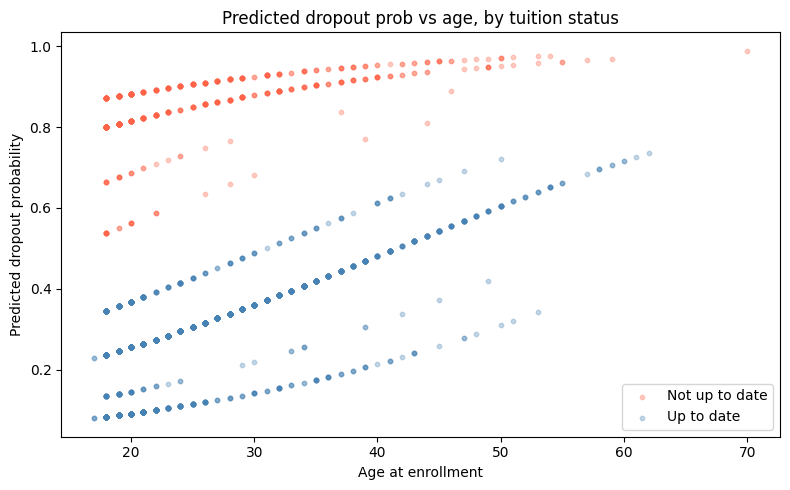

Tuition fees up to date
0    0.860675
1    0.248090
Name: dropout_prob, dtype: float64

Avg difference: 0.613


In [27]:
proba2 = lr2.predict_proba(X2)[:, 1]

students['dropout_prob'] = proba2
tuition_groups = students.groupby('Tuition fees up to date')

fig, ax = plt.subplots(figsize=(8, 5))
colors = {0: 'tomato', 1: 'steelblue'}
labels = {0: 'Not up to date', 1: 'Up to date'}
for val, grp in tuition_groups:
    ax.scatter(grp['Age at enrollment'], grp['dropout_prob'],
               alpha=0.3, s=10, color=colors[val], label=labels[val])
ax.set_xlabel('Age at enrollment')
ax.set_ylabel('Predicted dropout probability')
ax.set_title('Predicted dropout prob vs age, by tuition status')
ax.legend()
plt.tight_layout()
plt.show()

mean_prob_by_tuition = students.groupby('Tuition fees up to date')['dropout_prob'].mean()
print(mean_prob_by_tuition)
print(f"\nAvg difference: {mean_prob_by_tuition[0] - mean_prob_by_tuition[1]:.3f}")

The gap between the two groups is pretty consistent across ages, but the spread widens a bit at older ages since the age coefficient compounds with the tuition effect. On average being up to date on tuition lowers predicted dropout probability by a lot.

In [28]:
y2_pred = lr2.predict(X2)
cm2 = pd.crosstab(y2, pd.Series(y2_pred, index=y2.index), rownames=['actual'], colnames=['predicted'])
print(cm2)
print(f"\nAccuracy: {accuracy_score(y2, y2_pred):.3f}")

predicted     0    1
actual              
0          2841  162
1           891  530

Accuracy: 0.762


Accuracy is decent. The model is better at identifying non-dropouts than actual dropouts, which makes sense given the data is imbalanced.

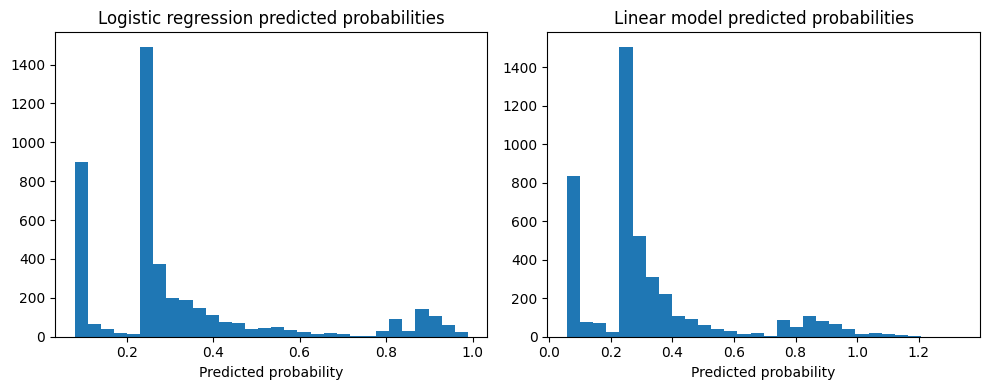

Linear model out-of-range predictions: 0 below 0, 57 above 1
Linear model total out-of-range predictions: 57


In [29]:
lm2 = LinearRegression().fit(X2, y2)
lm2_proba = lm2.predict(X2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(proba2, bins=30)
axes[0].set_title('Logistic regression predicted probabilities')
axes[0].set_xlabel('Predicted probability')
axes[1].hist(lm2_proba, bins=30)
axes[1].set_title('Linear model predicted probabilities')
axes[1].set_xlabel('Predicted probability')
plt.tight_layout()
plt.show()
lower_out_of_range = (lm2_proba < 0).sum()
upper_out_of_range = (lm2_proba > 1).sum()
print(f"Linear model out-of-range predictions: {lower_out_of_range} below 0, {upper_out_of_range} above 1")

print(f"Linear model total out-of-range predictions: {lower_out_of_range + upper_out_of_range}")

The linear model predicts some probabilities outside of [0, 1] which doesn't make sense. The logistic regression stays in bounds. Both are picking up the same general pattern but the linear model histogram has a tail that goes above one. The logistic regression is more appropriate here.

The highest risk students are those who are debtors, not up to date on tuition, and older at enrollment. Interventions could be financial aid counseling or emergency funds for students who fall behind on tuition, since that seems to be the biggest driver. You could also flag students in their first semester who have these characteristics and check in with them early.

In [30]:
feat_multi = ['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']
X_multi = students[feat_multi]
y_multi = students['Target']

mlr = LogisticRegression(max_iter=1000).fit(X_multi, y_multi)

y_multi_pred = mlr.predict(X_multi)
cm_multi = pd.crosstab(y_multi, pd.Series(y_multi_pred, index=y_multi.index),
                       rownames=['actual'], colnames=['predicted'])
print(cm_multi)
print(f"\nClasses predicted (hard): {np.unique(y_multi_pred)}")

proba_multi = mlr.predict_proba(X_multi)
print(f"Classes (proba columns): {mlr.classes_}")
print(pd.DataFrame(proba_multi, columns=mlr.classes_).describe())

predicted  Dropout  Graduate
actual                      
Dropout       1054       367
Enrolled       280       514
Graduate       146      2063

Classes predicted (hard): ['Dropout' 'Graduate']
Classes (proba columns): ['Dropout' 'Enrolled' 'Graduate']
            Dropout     Enrolled     Graduate
count  4.424000e+03  4424.000000  4424.000000
mean   3.212229e-01     0.179474     0.499303
std    2.866920e-01     0.066308     0.287579
min    9.564711e-07     0.000279     0.002135
25%    1.178080e-01     0.140644     0.172735
50%    1.842268e-01     0.176983     0.603104
75%    5.898657e-01     0.212669     0.705209
max    9.601568e-01     0.327752     0.999720


The hard classification only predicts Dropout and Graduate but never predicts Enrolled. Enrolled gets split between those two classes. The predicted probabilities do assign nonzero prob to all three classes for every observation, so the model knows Enrolled exists, but the probability is always low enough that Dropout or Graduate wins.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [31]:
circ_cols = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
circ = pd.read_csv('../data/cirrhosis.csv', usecols=circ_cols)
print(circ.shape)
print(circ.isna().sum())
circ.head()

(418, 5)
Status         0
Drug         106
Edema          0
Bilirubin      0
Stage          6
dtype: int64


,Status,Drug,Edema,Bilirubin,Stage
0,D,D-penicillamine,Y,14.5,4.0
1,C,D-penicillamine,N,1.1,3.0
2,D,D-penicillamine,S,1.4,4.0
3,D,D-penicillamine,S,1.8,4.0
4,CL,Placebo,N,3.4,3.0


In [32]:
circ = circ.dropna()
print(f"After dropping NAs: {circ.shape}")

circ['alive'] = (circ['Status'] != 'D').astype(int)
circ['drug_bin'] = (circ['Drug'] == 'D-penicillamine').astype(int)
circ['edema_S'] = (circ['Edema'] == 'S').astype(int)
circ['edema_Y'] = (circ['Edema'] == 'Y').astype(int)

circ['alive'].value_counts()

After dropping NAs: (312, 5)


alive
1    187
0    125
Name: count, dtype: int64

There were some missing values so I dropped those rows. I made drug binary and created dummies for Edema (N is the baseline).

In [ ]:
feat3 = ['drug_bin', 'edema_S', 'edema_Y', 'Bilirubin']
X3 = circ[feat3]
y3 = circ['alive']

lr3 = LogisticRegression(max_iter=1000).fit(X3, y3)
coef3 = pd.DataFrame({'feature': feat3, 'coef': lr3.coef_[0]})
print(coef3)

     feature      coef
0   drug_bin -0.231952
1    edema_S -0.451483
2    edema_Y -1.613160
3  Bilirubin -0.351450


Drug has a negative coefficient (-0.23), so D-penicillamine is actually associated with slightly lower predicted survival odds compared to placebo so it does not improve survival=. Bilirubin has a negative coefficient, so higher bilirubin predicts lower survival, which makes sense since it's a marker of liver stress. Edema S and Y both have negative coefficients relative to no edema, and Y is much worse than S (-1.61 vs -0.45), which also makes biological sense: edema that doesn't respond to diuretics means the disease is probably more severe.

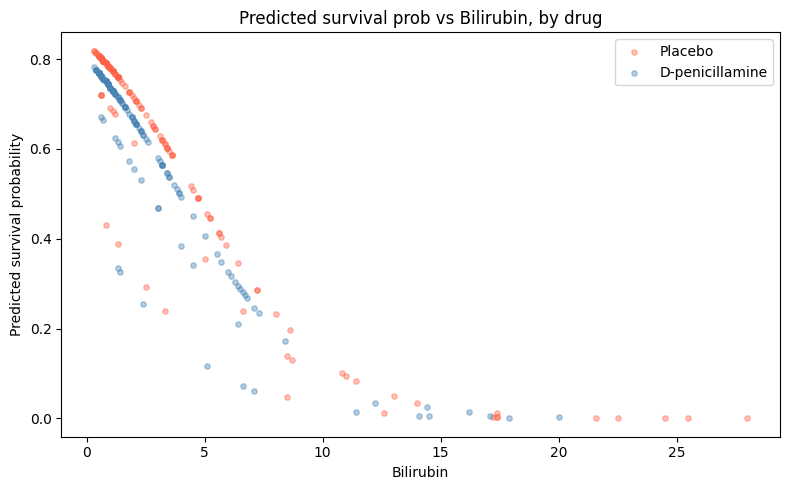

drug_bin
0    0.608971
1    0.589990
Name: surv_prob, dtype: float64

Avg difference: -0.019


In [34]:
proba3 = lr3.predict_proba(X3)[:, 1]
circ['surv_prob'] = proba3

fig, ax = plt.subplots(figsize=(8, 5))
drug_colors = {0: 'tomato', 1: 'steelblue'}
drug_labels = {0: 'Placebo', 1: 'D-penicillamine'}
for val, grp in circ.groupby('drug_bin'):
    ax.scatter(grp['Bilirubin'], grp['surv_prob'],
               alpha=0.4, s=15, color=drug_colors[val], label=drug_labels[val])
ax.set_xlabel('Bilirubin')
ax.set_ylabel('Predicted survival probability')
ax.set_title('Predicted survival prob vs Bilirubin, by drug')
ax.legend()
plt.tight_layout()
plt.show()

mean_surv = circ.groupby('drug_bin')['surv_prob'].mean()
print(mean_surv)
print(f"\nAvg difference: {mean_surv[1] - mean_surv[0]:.3f}")

The two groups track each other closely across all bilirubin values since the drug coefficient is small. There is a small gap favoring the placebo group, which matches the negative drug coefficient. At very high bilirubin both groups are predicted to have low survival. On average the drug has slightly lower predicted survival probability compared to placebo.

In [35]:
y3_pred = lr3.predict(X3)
cm3 = pd.crosstab(y3, pd.Series(y3_pred, index=y3.index), rownames=['actual'], colnames=['predicted'])
print(cm3)
print(f"\nAccuracy: {accuracy_score(y3, y3_pred):.3f}")

predicted   0    1
actual            
0          59   66
1          16  171

Accuracy: 0.737


Accuracy is alright. The model mostly predicts survival for everyone since there are more alive cases in the data, but it does pick up some of the deaths.

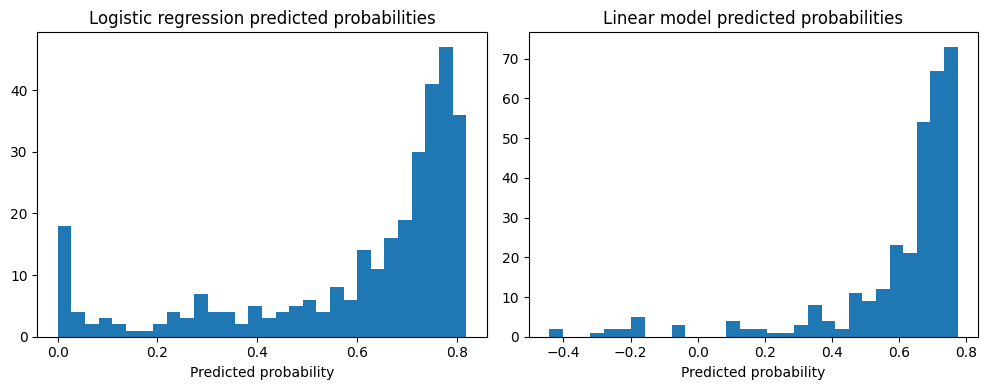

Linear model out-of-range: 15


In [36]:
lm3 = LinearRegression().fit(X3, y3)
lm3_proba = lm3.predict(X3)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(proba3, bins=30)
axes[0].set_title('Logistic regression predicted probabilities')
axes[0].set_xlabel('Predicted probability')
axes[1].hist(lm3_proba, bins=30)
axes[1].set_title('Linear model predicted probabilities')
axes[1].set_xlabel('Predicted probability')
plt.tight_layout()
plt.show()

print(f"Linear model out-of-range: {((lm3_proba < 0) | (lm3_proba > 1)).sum()}")

Same pattern as Q2. The linear model produces predictions above 1 for some patients, which makes no sense as a probability. This one also predicts some below 0. Logistic keeps everything in [0, 1]. Both are working off the same features so the general trend is similar but the logistic predictions are better calibrated

In [37]:
feat3b = ['edema_S', 'edema_Y', 'Bilirubin']
X3b = circ[feat3b]
y3b = circ['Stage'].astype(str)

mlr3 = LogisticRegression(max_iter=1000).fit(X3b, y3b)

y3b_pred = mlr3.predict(X3b)
cm3b = pd.crosstab(y3b, pd.Series(y3b_pred, index=y3b.index),
                   rownames=['actual'], colnames=['predicted'])
print(cm3b)
print(f"\nClasses predicted (hard): {np.unique(y3b_pred)}")

proba3b = mlr3.predict_proba(X3b)
print(f"Classes (proba): {mlr3.classes_}")
print(pd.DataFrame(proba3b, columns=mlr3.classes_).describe())

predicted  3.0  4.0
actual             
1.0         16    0
2.0         63    4
3.0        105   15
4.0         79   30

Classes predicted (hard): ['3.0' '4.0']
Classes (proba): ['1.0' '2.0' '3.0' '4.0']
                1.0         2.0         3.0         4.0
count  3.120000e+02  312.000000  312.000000  312.000000
mean   5.125179e-02    0.214685    0.384666    0.349397
std    3.555501e-02    0.060985    0.061358    0.133680
min    2.982598e-09    0.012899    0.104528    0.255662
25%    1.802610e-02    0.192306    0.386861    0.270305
50%    5.444797e-02    0.246846    0.395635    0.292649
75%    8.488615e-02    0.253397    0.412623    0.373223
max    1.100461e-01    0.255032    0.428496    0.882573


The hard classification only predicts stages 3 and 4. The model can't separate the lower stages well enough to ever choose them as the most likely class. The predicted probabilities do assign nonzero values to all four stages for every row, so the model knows stages 1 and 2 exist, but those probabilities are always low enough that stage 3 or 4 wins.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?


The derivative of $\hat{y}$ with respect to $x_k$ is just $b_k$. It's a constant, doesn't depend on where you are in the data. For a 1 unit increase in $x_k$, the predicted value goes up by $b_k$.


2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?


Using chain rule, let $L = b \cdot x$. Then:

$$
\frac{\partial \hat{p}}{\partial x_k} = \frac{\partial \hat{p}}{\partial L} \cdot \frac{\partial L}{\partial x_k} = \hat{p}(1 - \hat{p}) \cdot b_k
$$

This changes as $x$ changes because $\hat{p}$ itself changes with $x$. This is different than linear because the effect is not constant. The term $\hat{p}(1-\hat{p})$ is maximized when $\hat{p} = 0.5$, where it equals $0.25$. At $\hat{p} = 0.5$, the derivative is $b_k / 4$, so the coefficient divided by 4 is a decent approximation of the effect near the split boundary. Away from 0.5 the approximation gets worse.


3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

A 1 unit increase in $x_k$ increases the log odds by $b_k$. The log odds is linear in the features, so it's the same as the linear case just in log-odds space rather than probability space.